In [1]:
# ładowanie MNIST
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.target = mnist.target.astype(np.uint8)
X = mnist["data"]
y = mnist["target"]

In [2]:
# dzielimy zbiór na dane treningowe i testowe
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [3]:
# zmniejszamy wymiarowośc z ponad 700 wymiarów (obrazki mają 28x28) do powiedzmy 150
from sklearn.decomposition import PCA

pca = PCA(n_components = 150)
# metoda fit_transform(...) służy do wykonania tego zadania
X_red = pca.fit_transform(X_train)
X_inv = pca.inverse_transform(X_red)

In [4]:
import matplotlib

def plot_digit(input_data, img_size=[28, 28]):
    img = input_data[0].reshape(img_size[0], img_size[1])
    plt.imshow(img, cmap=matplotlib.cm.binary)

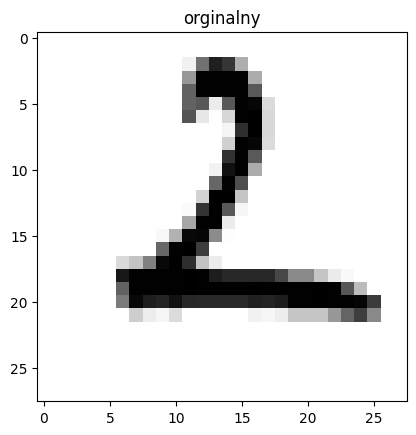

In [5]:
plot_digit(X_train[::2100])
plt.title("orginalny")
plt.show()

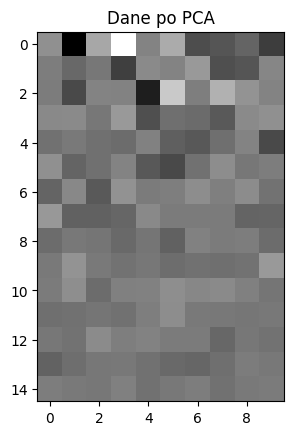

In [6]:
plot_digit(X_red[::2100], img_size=[15, 10])
plt.title("Dane po PCA")
plt.show()

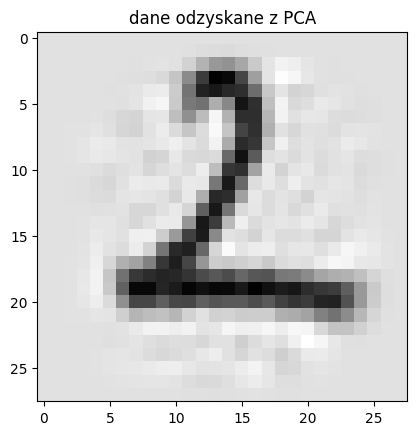

In [7]:
plot_digit(X_inv[::2100])
plt.title("dane odzyskane z PCA")
plt.show()

In [8]:
# incrementalPCA

from sklearn.decomposition import IncrementalPCA

batch_size = 100
pca_incr = IncrementalPCA(n_components=150)
for X_batch in np.array_split(X_train, batch_size):
    pca_incr.partial_fit(X_batch)

X_red= pca_incr.transform(X_train)
X_inv = pca_incr.inverse_transform(X_red)

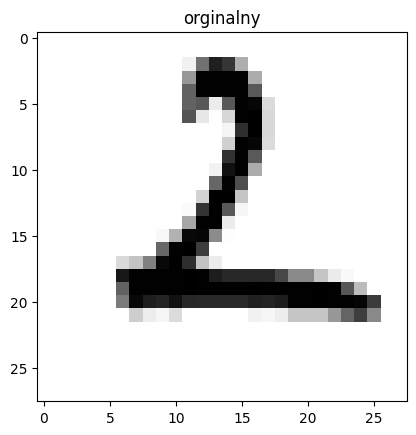

In [9]:
plot_digit(X_train[::2100])
plt.title("orginalny")
plt.show()

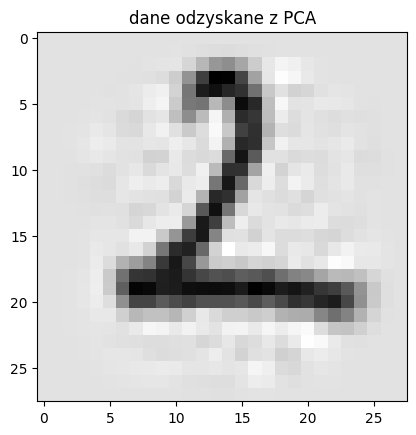

In [10]:
plot_digit(X_inv[::2100])
plt.title("dane odzyskane z PCA")
plt.show()